# 8.3 Second-Order Optimization Methods

First-order methods use only the gradient and can be slow to converge on ill-conditioned problems. **Second-order methods** incorporate curvature information (via the Hessian or its approximation) to dramatically accelerate convergence.

This notebook covers:
1. **Newton's method** — the gold standard second-order optimizer
2. **BFGS and L-BFGS** — quasi-Newton methods that approximate the Hessian
3. **Trust region methods** — safe optimization on nonconvex landscapes

## Real-World Scenario

A biotech company is fitting an **enzyme kinetics model** to experimental data. The relationship between substrate concentration and reaction velocity follows the Michaelis-Menten equation with substrate inhibition — a nonlinear model whose loss landscape has strong curvature differences across parameter directions. First-order methods zig-zag slowly; second-order methods exploit curvature to converge much faster.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## 1. Newton's Method

Newton's method uses a **second-order Taylor approximation** of the loss around the current iterate $\boldsymbol{\theta}_t$:

$$\mathcal{L}_{\text{quad}}(\boldsymbol{\theta}) = \mathcal{L}(\boldsymbol{\theta}_t) + \mathbf{g}_t^\top(\boldsymbol{\theta} - \boldsymbol{\theta}_t) + \frac{1}{2}(\boldsymbol{\theta} - \boldsymbol{\theta}_t)^\top \mathbf{H}_t (\boldsymbol{\theta} - \boldsymbol{\theta}_t)$$

where $\mathbf{g}_t = \nabla\mathcal{L}(\boldsymbol{\theta}_t)$ is the gradient and $\mathbf{H}_t = \nabla^2\mathcal{L}(\boldsymbol{\theta}_t)$ is the **Hessian**.

Setting $\nabla\mathcal{L}_{\text{quad}} = 0$ gives the **Newton update**:

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta_t \mathbf{H}_t^{-1} \mathbf{g}_t$$

The Newton **direction** is $\mathbf{d}_t = -\mathbf{H}_t^{-1}\mathbf{g}_t$. The inverse Hessian "undoes" the curvature skew, converting elongated elliptical contours into circular ones where steepest descent works perfectly.

### Why It's Faster

On a quadratic $\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2}\boldsymbol{\theta}^\top\mathbf{A}\boldsymbol{\theta} + \mathbf{b}^\top\boldsymbol{\theta} + c$, we have $\mathbf{H} = \mathbf{A}$ and $\mathbf{g} = \mathbf{A}\boldsymbol{\theta} + \mathbf{b}$, so:

$$\boldsymbol{\theta}_1 = \boldsymbol{\theta}_0 - \mathbf{A}^{-1}(\mathbf{A}\boldsymbol{\theta}_0 + \mathbf{b}) = -\mathbf{A}^{-1}\mathbf{b} = \boldsymbol{\theta}^*$$

Newton's method converges in **exactly one step** on quadratics, regardless of the condition number.

> **Why use iterative methods on a quadratic we can solve directly?** We can't — and we wouldn't. The quadratic is a **teaching device**: a controlled setting where we know the answer, so we can visualize how each optimizer behaves. The real payoff comes on **nonlinear problems** (Rosenbrock in §4, enzyme kinetics in §5) where no closed-form solution exists and iterative optimization is the only option.

In [2]:
# --- Helpers for quadratic objectives ---
def quadratic_loss(theta, A, b, c):
    return 0.5 * theta @ A @ theta + b @ theta + c

def quadratic_grad(theta, A, b):
    return A @ theta + b

# Ill-conditioned quadratic (κ ≈ 30)
A = np.array([[20.0, 5.0],
              [5.0,  2.0]])
b = np.array([-14.0, -6.0])
c = 0.0

theta_star = -np.linalg.solve(A, b)
eigvals = np.linalg.eigvalsh(A)
kappa = eigvals.max() / eigvals.min()

print(f"Condition number κ = {kappa:.1f}")
print(f"Optimal θ* = [{theta_star[0]:.4f}, {theta_star[1]:.4f}]")

Condition number κ = 30.2
Optimal θ* = [-0.1333, 3.3333]


In [3]:
def gradient_descent(grad_fn, theta0, lr, n_steps, **kwargs):
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(n_steps):
        g = grad_fn(theta, **kwargs)
        theta = theta - lr * g
        path.append(theta.copy())
    return np.array(path)

def newton_method(loss_fn, grad_fn, hess_fn, theta0, n_steps, eta=1.0, **kwargs):
    """Newton's method with optional step size."""
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(n_steps):
        g = grad_fn(theta, **kwargs)
        H = hess_fn(theta, **kwargs)
        d = -np.linalg.solve(H, g)  # Newton direction: d = -H^{-1} g
        theta = theta + eta * d
        path.append(theta.copy())
    return np.array(path)

# Run both methods from the same starting point
theta0 = theta_star + np.array([-2.5, 3.0])

path_gd = gradient_descent(quadratic_grad, theta0, lr=0.04, n_steps=50, A=A, b=b)
path_newton = newton_method(
    lambda t, **kw: quadratic_loss(t, A, b, c),
    lambda t, **kw: quadratic_grad(t, A, b),
    lambda t, **kw: A,  # Hessian is constant for quadratics
    theta0, n_steps=5
)

print(f"GD after 50 steps:      θ = [{path_gd[-1][0]:.6f}, {path_gd[-1][1]:.6f}]")
print(f"Newton after 1 step:    θ = [{path_newton[1][0]:.6f}, {path_newton[1][1]:.6f}]")
print(f"True optimum:           θ* = [{theta_star[0]:.6f}, {theta_star[1]:.6f}]")

GD after 50 steps:      θ = [-0.345525, 4.152207]
Newton after 1 step:    θ = [-0.133333, 3.333333]
True optimum:           θ* = [-0.133333, 3.333333]


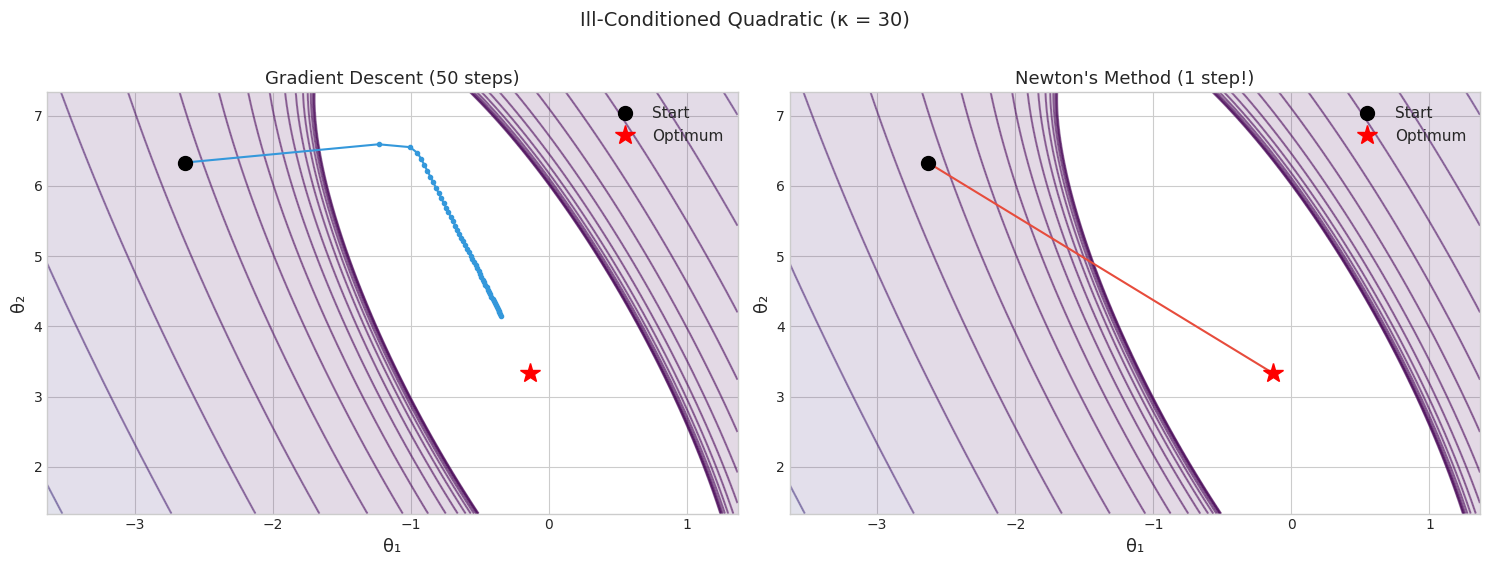

Newton converges in 1 step on any quadratic, regardless of condition number.
GD still zig-zags after 50 steps due to the elongated contours.


In [4]:
# Visualize: GD vs Newton on the ill-conditioned quadratic
t1 = np.linspace(theta_star[0] - 3.5, theta_star[0] + 1.5, 200)
t2 = np.linspace(theta_star[1] - 2, theta_star[1] + 4, 200)
T1, T2 = np.meshgrid(t1, t2)
Z = np.array([[quadratic_loss(np.array([t1i, t2j]), A, b, c)
               for t1i, t2j in zip(row1, row2)]
              for row1, row2 in zip(T1, T2)])

levels = np.logspace(-1, 3, 20)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, path, title, color, n_show in [
    (axes[0], path_gd, f'Gradient Descent (50 steps)', '#3498db', 50),
    (axes[1], path_newton, f'Newton\'s Method (1 step!)', '#e74c3c', 5),
]:
    ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)
    ax.plot(path[:n_show+1, 0], path[:n_show+1, 1], '.-', color=color,
            markersize=6, linewidth=1.5)
    ax.plot(*theta0, 'ko', markersize=10, label='Start')
    ax.plot(*theta_star, 'r*', markersize=15, label='Optimum')
    ax.set_xlabel('θ₁', fontsize=13)
    ax.set_ylabel('θ₂', fontsize=13)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=11)

plt.suptitle(f'Ill-Conditioned Quadratic (κ = {kappa:.0f})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Newton converges in 1 step on any quadratic, regardless of condition number.")
print("GD still zig-zags after 50 steps due to the elongated contours.")

## 2. Newton's Method on Nonconvex Functions

Newton's method can fail on **nonconvex** functions. If the Hessian is not positive definite, the Newton direction $\mathbf{d}_t = -\mathbf{H}_t^{-1}\mathbf{g}_t$ may point **uphill** — toward a local maximum or saddle point.

This is because the quadratic approximation $\mathcal{L}_{\text{quad}}$ models a bowl, but the true function might curve the other way. The "minimum" of a concave quadratic is actually a maximum.

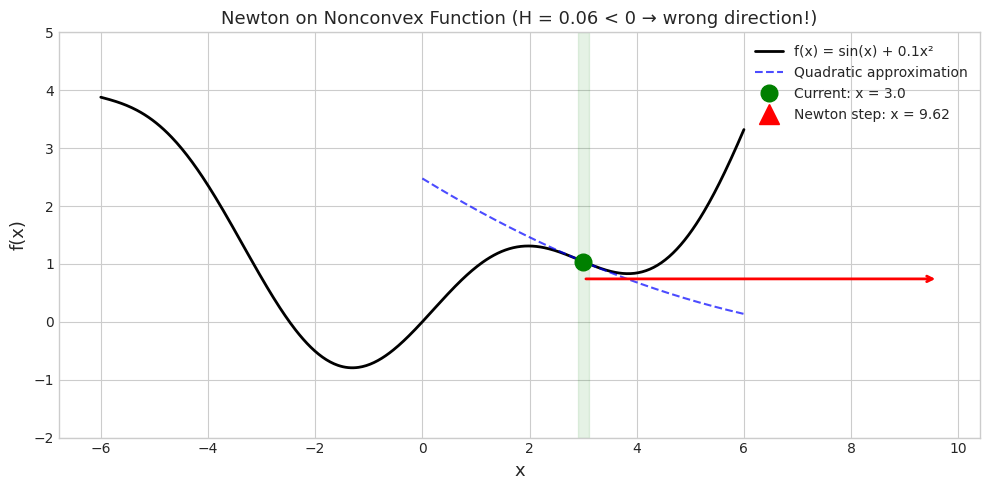

At x = 3.0: gradient = -0.390, Hessian = 0.059
Hessian is NEGATIVE → quadratic opens downward → Newton moves to its 'minimum'
which is actually a maximum of the quadratic approximation.
Newton step goes to x = 9.62, which is WORSE (higher f).


In [5]:
# A 1D nonconvex function where Newton heads toward a maximum
def f_nonconvex(x):
    return np.sin(x) + 0.1 * x**2

def f_nonconvex_grad(x):
    return np.cos(x) + 0.2 * x

def f_nonconvex_hess(x):
    return -np.sin(x) + 0.2

x_plot = np.linspace(-6, 6, 500)

# Start near a region where the Hessian is negative
x_start = 3.0
g_start = f_nonconvex_grad(x_start)
H_start = f_nonconvex_hess(x_start)

# Newton step
x_newton = x_start - g_start / H_start

# Quadratic approximation
x_quad = np.linspace(x_start - 3, x_start + 3, 200)
f_quad = f_nonconvex(x_start) + g_start * (x_quad - x_start) + 0.5 * H_start * (x_quad - x_start)**2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_plot, f_nonconvex(x_plot), 'k-', linewidth=2, label='f(x) = sin(x) + 0.1x²')
ax.plot(x_quad, f_quad, 'b--', linewidth=1.5, alpha=0.7, label='Quadratic approximation')
ax.plot(x_start, f_nonconvex(x_start), 'go', markersize=12, zorder=5, label=f'Current: x = {x_start:.1f}')
ax.plot(x_newton, f_nonconvex(x_newton), 'r^', markersize=14, zorder=5,
        label=f'Newton step: x = {x_newton:.2f}')
ax.annotate('', xy=(x_newton, f_nonconvex(x_start) - 0.3),
            xytext=(x_start, f_nonconvex(x_start) - 0.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax.axvspan(x_start - 0.1, x_start + 0.1, alpha=0.1, color='green')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title(f'Newton on Nonconvex Function (H = {H_start:.2f} < 0 → wrong direction!)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-2, 5)
plt.tight_layout()
plt.show()

print(f"At x = {x_start:.1f}: gradient = {g_start:.3f}, Hessian = {H_start:.3f}")
print(f"Hessian is NEGATIVE → quadratic opens downward → Newton moves to its 'minimum'")
print(f"which is actually a maximum of the quadratic approximation.")
print(f"Newton step goes to x = {x_newton:.2f}, which is WORSE (higher f).")

## 3. BFGS: Quasi-Newton Methods

Computing and inverting the full Hessian costs $O(D^3)$ per step. **Quasi-Newton methods** build an approximation to the Hessian iteratively, using only gradient information.

### The BFGS Update

BFGS (Broyden-Fletcher-Goldfarb-Shanno) maintains an approximation $\mathbf{B}_t \approx \mathbf{H}_t$ that is updated with a **rank-2 correction** at each step:

$$\mathbf{B}_{t+1} = \mathbf{B}_t + \frac{\mathbf{y}_t \mathbf{y}_t^\top}{\mathbf{y}_t^\top \mathbf{s}_t} - \frac{(\mathbf{B}_t \mathbf{s}_t)(\mathbf{B}_t \mathbf{s}_t)^\top}{\mathbf{s}_t^\top \mathbf{B}_t \mathbf{s}_t}$$

where:
- $\mathbf{s}_t = \boldsymbol{\theta}_t - \boldsymbol{\theta}_{t-1}$ — the parameter step
- $\mathbf{y}_t = \mathbf{g}_t - \mathbf{g}_{t-1}$ — the gradient difference

### Inverse Hessian Form

BFGS can also directly update an approximation to the **inverse** Hessian $\mathbf{C}_t \approx \mathbf{H}_t^{-1}$:

$$\mathbf{C}_{t+1} = \left(\mathbf{I} - \frac{\mathbf{s}_t \mathbf{y}_t^\top}{\mathbf{y}_t^\top \mathbf{s}_t}\right) \mathbf{C}_t \left(\mathbf{I} - \frac{\mathbf{y}_t \mathbf{s}_t^\top}{\mathbf{y}_t^\top \mathbf{s}_t}\right) + \frac{\mathbf{s}_t \mathbf{s}_t^\top}{\mathbf{y}_t^\top \mathbf{s}_t}$$

This avoids the $O(D^3)$ cost of solving a linear system at each step — only $O(D^2)$ for matrix-vector products.

### Wolfe Conditions

BFGS requires a line search satisfying the **Wolfe conditions**:

1. **Armijo** (sufficient decrease): $\mathcal{L}(\boldsymbol{\theta}_t + \eta\mathbf{d}_t) \leq \mathcal{L}(\boldsymbol{\theta}_t) + c_1 \eta \mathbf{d}_t^\top\mathbf{g}_t$
2. **Curvature**: $\nabla\mathcal{L}(\boldsymbol{\theta}_t + \eta\mathbf{d}_t)^\top\mathbf{d}_t \geq c_2 \mathbf{d}_t^\top\mathbf{g}_t$

These ensure the Hessian approximation remains **positive definite**.

In [6]:
def wolfe_line_search(loss_fn, grad_fn, theta, d, g, c1=1e-4, c2=0.9,
                      eta_init=1.0, max_iter=25, **kwargs):
    """Backtracking line search satisfying both Wolfe conditions."""
    eta = eta_init
    f0 = loss_fn(theta, **kwargs)
    dg = d @ g  # directional derivative
    for _ in range(max_iter):
        theta_new = theta + eta * d
        # Check Armijo condition
        if loss_fn(theta_new, **kwargs) > f0 + c1 * eta * dg:
            eta *= 0.5
            continue
        # Check curvature condition
        g_new = grad_fn(theta_new, **kwargs)
        if g_new @ d < c2 * dg:
            eta *= 2.0
            continue
        return eta
    return eta


def bfgs(loss_fn, grad_fn, theta0, n_steps, **kwargs):
    """BFGS quasi-Newton method with Wolfe line search."""
    D = len(theta0)
    theta = theta0.copy()
    C = np.eye(D)  # Initial inverse Hessian approximation: C_0 = I
    g = grad_fn(theta, **kwargs)
    path = [theta.copy()]
    losses = [loss_fn(theta, **kwargs)]

    for _ in range(n_steps):
        # Search direction
        d = -C @ g

        # Line search
        eta = wolfe_line_search(loss_fn, grad_fn, theta, d, g, **kwargs)

        # Take step: s_t = η·d = θ_{t+1} − θ_t (the parameter step used in the BFGS update)
        s = eta * d
        theta_new = theta + s
        g_new = grad_fn(theta_new, **kwargs)

        # BFGS inverse Hessian update (Eq. 8.48)
        y = g_new - g
        sy = s @ y
        if sy > 1e-10:  # Skip update if curvature condition is not met
            rho = 1.0 / sy
            I = np.eye(D)
            V = I - rho * np.outer(s, y)
            C = V @ C @ V.T + rho * np.outer(s, s)

        theta = theta_new
        g = g_new
        path.append(theta.copy())
        losses.append(loss_fn(theta, **kwargs))

    return np.array(path), np.array(losses)

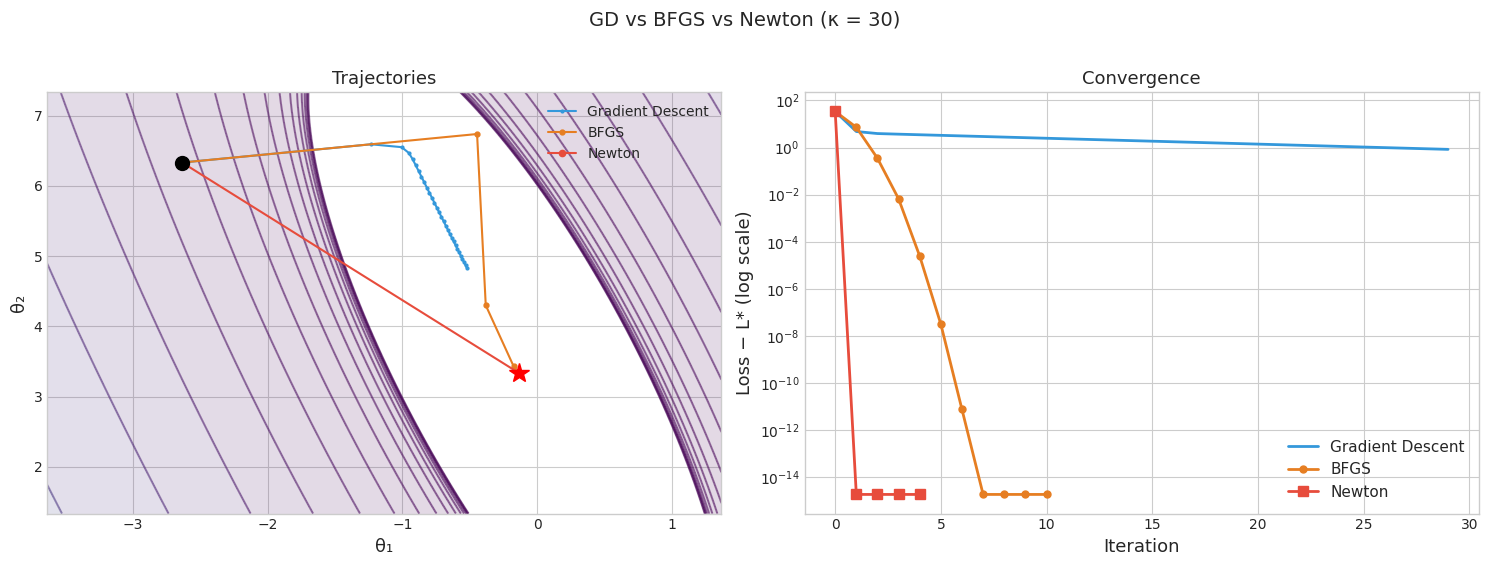

Newton converges in 1 step (exact Hessian on a quadratic).
BFGS starts with C₀ = I (like GD) but quickly builds up curvature information.
GD zig-zags due to the condition number κ = 30.


In [7]:
# Compare GD, Newton, and BFGS on the ill-conditioned quadratic
loss_fn = lambda t, **kw: quadratic_loss(t, A, b, c)
grad_fn = lambda t, **kw: quadratic_grad(t, A, b)
hess_fn = lambda t, **kw: A

path_gd = gradient_descent(quadratic_grad, theta0, lr=0.04, n_steps=50, A=A, b=b)
path_newton = newton_method(loss_fn, grad_fn, hess_fn, theta0, n_steps=10)
path_bfgs, losses_bfgs = bfgs(loss_fn, grad_fn, theta0, n_steps=10)

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: trajectories
ax = axes[0]
ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)

for path, label, color, ms in [
    (path_gd[:30], 'Gradient Descent', '#3498db', 4),
    (path_bfgs[:15], 'BFGS', '#e67e22', 7),
    (path_newton[:5], 'Newton', '#e74c3c', 9),
]:
    ax.plot(path[:, 0], path[:, 1], '.-', color=color, markersize=ms, linewidth=1.5, label=label)

ax.plot(*theta0, 'ko', markersize=10)
ax.plot(*theta_star, 'r*', markersize=15)
ax.set_xlabel('θ₁', fontsize=13)
ax.set_ylabel('θ₂', fontsize=13)
ax.set_title('Trajectories', fontsize=13)
ax.legend(fontsize=10)

# Right: loss curves
ax = axes[1]
opt_loss = quadratic_loss(theta_star, A, b, c)

losses_gd = [quadratic_loss(p, A, b, c) - opt_loss + 1e-16 for p in path_gd]
losses_newton = [quadratic_loss(p, A, b, c) - opt_loss + 1e-16 for p in path_newton]
losses_bfgs_plot = losses_bfgs - opt_loss + 1e-16

ax.semilogy(losses_gd[:30], linewidth=2, color='#3498db', label='Gradient Descent')
ax.semilogy(losses_bfgs_plot[:15], linewidth=2, color='#e67e22', label='BFGS', marker='o', markersize=5)
ax.semilogy(losses_newton[:5], linewidth=2, color='#e74c3c', label='Newton', marker='s', markersize=7)

ax.set_xlabel('Iteration', fontsize=13)
ax.set_ylabel('Loss − L* (log scale)', fontsize=13)
ax.set_title('Convergence', fontsize=13)
ax.legend(fontsize=11)

plt.suptitle(f'GD vs BFGS vs Newton (κ = {kappa:.0f})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Newton converges in 1 step (exact Hessian on a quadratic).")
print(f"BFGS starts with C₀ = I (like GD) but quickly builds up curvature information.")
print(f"GD zig-zags due to the condition number κ = {kappa:.0f}.")

### How BFGS Learns the Hessian

BFGS starts with $\mathbf{C}_0 = \mathbf{I}$ (the identity — equivalent to gradient descent on the first step). With each step, it incorporates new curvature information from the gradient differences $\mathbf{y}_t$. Let's watch the inverse Hessian approximation converge to the true $\mathbf{H}^{-1}$.

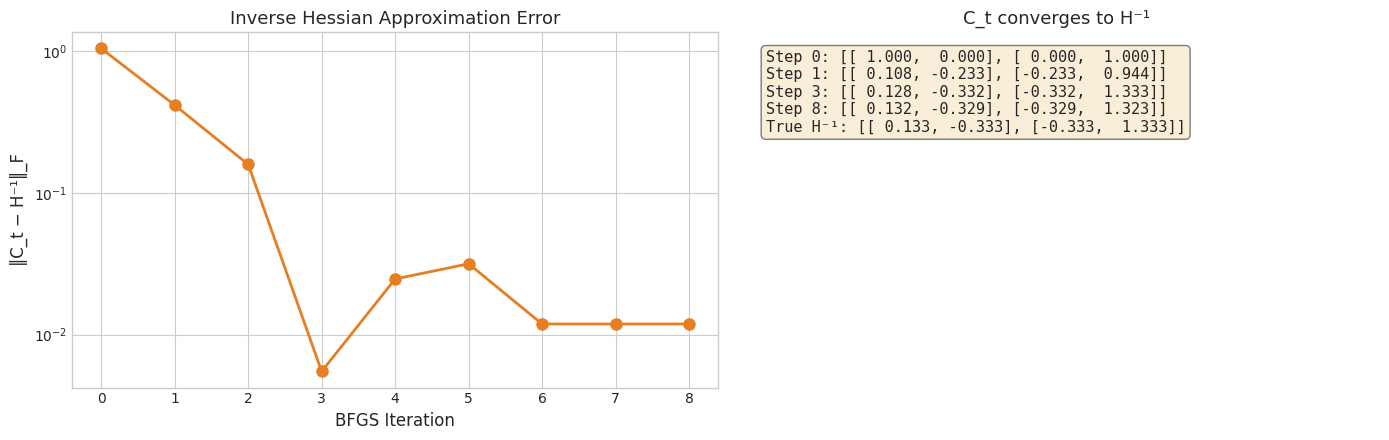

In [8]:
# Track the inverse Hessian approximation over BFGS iterations
D = 2
theta = theta0.copy()
C = np.eye(D)
g = quadratic_grad(theta, A, b)
C_true = np.linalg.inv(A)

C_history = [C.copy()]
approx_error = [np.linalg.norm(C - C_true, 'fro')]

for step in range(8):
    d = -C @ g
    eta = wolfe_line_search(loss_fn, grad_fn, theta, d, g)
    s = eta * d
    theta_new = theta + s
    g_new = quadratic_grad(theta_new, A, b)
    y = g_new - g
    sy = s @ y
    if sy > 1e-10:
        rho = 1.0 / sy
        I = np.eye(D)
        V = I - rho * np.outer(s, y)
        C = V @ C @ V.T + rho * np.outer(s, s)
    theta = theta_new
    g = g_new
    C_history.append(C.copy())
    approx_error.append(np.linalg.norm(C - C_true, 'fro'))

# Display convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: Frobenius norm error
ax = axes[0]
ax.semilogy(approx_error, 'o-', color='#e67e22', linewidth=2, markersize=8)
ax.set_xlabel('BFGS Iteration', fontsize=12)
ax.set_ylabel('‖C_t − H⁻¹‖_F', fontsize=12)
ax.set_title('Inverse Hessian Approximation Error', fontsize=13)

# Right: Show the matrices side by side
ax = axes[1]
steps_to_show = [0, 1, 3, len(C_history)-1]
labels = [f'Step {i}' for i in steps_to_show]
labels[-1] = f'Step {steps_to_show[-1]} (final)'

text_lines = []
for step_idx in steps_to_show:
    Ci = C_history[step_idx]
    text_lines.append(f"Step {step_idx}: [[{Ci[0,0]:6.3f}, {Ci[0,1]:6.3f}], [{Ci[1,0]:6.3f}, {Ci[1,1]:6.3f}]]")
text_lines.append(f"True H⁻¹: [[{C_true[0,0]:6.3f}, {C_true[0,1]:6.3f}], [{C_true[1,0]:6.3f}, {C_true[1,1]:6.3f}]]")

ax.text(0.05, 0.95, '\n'.join(text_lines), transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title('C_t converges to H⁻¹', fontsize=13)
ax.axis('off')

plt.tight_layout()
plt.show()

### L-BFGS: Limited-Memory BFGS *

Storing the full $D \times D$ matrix $\mathbf{C}_t$ costs $O(D^2)$ memory — infeasible for large-scale problems. **L-BFGS** keeps only the $M$ most recent $(\mathbf{s}_t, \mathbf{y}_t)$ pairs and implicitly represents $\mathbf{C}_t$ with $O(MD)$ storage. Typically $M \in [5, 20]$ suffices.

### The Two-Loop Recursion

Rather than storing $\mathbf{C}_t$ explicitly, L-BFGS computes the product $\mathbf{C}_t \mathbf{g}_t$ directly via a clever **two-loop recursion**. Given the $M$ most recent pairs $\{(\mathbf{s}_i, \mathbf{y}_i)\}_{i=t-M}^{t-1}$ and an initial matrix $\mathbf{C}_t^0$ (typically a scaled identity):

**Loop 1 — Backward** (peel off BFGS layers): starting from $\mathbf{q} = \mathbf{g}_t$, for $i = t{-}1, \dots, t{-}M$:

$$\rho_i = \frac{1}{\mathbf{y}_i^\top \mathbf{s}_i}, \qquad \alpha_i = \rho_i \mathbf{s}_i^\top \mathbf{q}, \qquad \mathbf{q} \leftarrow \mathbf{q} - \alpha_i \mathbf{y}_i$$

**Apply initial Hessian**: $\mathbf{r} = \mathbf{C}_t^0\, \mathbf{q}$

**Loop 2 — Forward** (rebuild the layers): for $i = t{-}M, \dots, t{-}1$:

$$\beta_i = \rho_i \mathbf{y}_i^\top \mathbf{r}, \qquad \mathbf{r} \leftarrow \mathbf{r} + (\alpha_i - \beta_i) \mathbf{s}_i$$

The result $\mathbf{r} = \mathbf{C}_t \mathbf{g}_t$ is the search direction, computed in $O(MD)$ time with no matrix storage.

### Initial Hessian Scaling (Shanno Scaling)

The choice of $\mathbf{C}_t^0$ matters. Using $\mathbf{C}_t^0 = \mathbf{I}$ would ignore all scale information, so L-BFGS uses **Shanno scaling**:

$$\mathbf{C}_t^0 = \gamma_t \mathbf{I}, \qquad \gamma_t = \frac{\mathbf{s}_{t-1}^\top \mathbf{y}_{t-1}}{\mathbf{y}_{t-1}^\top \mathbf{y}_{t-1}}$$

This $\gamma_t$ approximates the **average eigenvalue of $\mathbf{H}^{-1}$** along the most recent step direction, giving the recursion a sensible starting scale. Without it, L-BFGS would need many more iterations to "learn" the right magnitude — with it, even $M = 5$ pairs often suffice for near-BFGS performance.

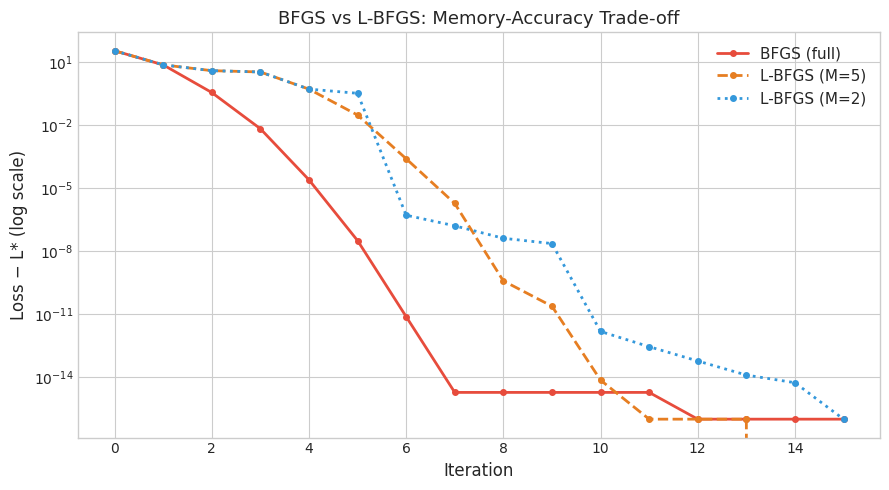

Storage comparison for D-dimensional problems:
  BFGS:       O(D²) — stores full D×D matrix
  L-BFGS(M):  O(MD) — stores M vector pairs (typically M = 5-20)
  sklearn uses L-BFGS as the default solver for logistic regression.


In [9]:
def lbfgs_two_loop(g, s_hist, y_hist):
    """L-BFGS two-loop recursion to compute H^{-1} g."""
    q = g.copy()
    m = len(s_hist)
    alphas = np.zeros(m)
    rhos = np.zeros(m)

    # First loop: backward
    for i in range(m - 1, -1, -1):
        rhos[i] = 1.0 / (y_hist[i] @ s_hist[i])
        alphas[i] = rhos[i] * (s_hist[i] @ q)
        q = q - alphas[i] * y_hist[i]

    # Initial scaling: gamma = (s^T y) / (y^T y)
    if m > 0:
        gamma = (s_hist[-1] @ y_hist[-1]) / (y_hist[-1] @ y_hist[-1])
        r = gamma * q
    else:
        r = q

    # Second loop: forward
    for i in range(m):
        beta = rhos[i] * (y_hist[i] @ r)
        r = r + (alphas[i] - beta) * s_hist[i]

    return r


def lbfgs(loss_fn, grad_fn, theta0, n_steps, memory=5, **kwargs):
    """L-BFGS with limited memory."""
    theta = theta0.copy()
    g = grad_fn(theta, **kwargs)
    s_hist, y_hist = [], []
    path = [theta.copy()]
    losses = [loss_fn(theta, **kwargs)]

    for _ in range(n_steps):
        # Compute search direction via two-loop recursion
        d = -lbfgs_two_loop(g, s_hist, y_hist)

        # Line search
        eta = wolfe_line_search(loss_fn, grad_fn, theta, d, g, **kwargs)

        s = eta * d
        theta_new = theta + s
        g_new = grad_fn(theta_new, **kwargs)
        y = g_new - g

        # Store pair (maintaining memory limit)
        if s @ y > 1e-10:
            s_hist.append(s.copy())
            y_hist.append(y.copy())
            if len(s_hist) > memory:
                s_hist.pop(0)
                y_hist.pop(0)

        theta = theta_new
        g = g_new
        path.append(theta.copy())
        losses.append(loss_fn(theta, **kwargs))

    return np.array(path), np.array(losses)


# Compare BFGS vs L-BFGS with different memory sizes
path_bfgs, losses_bfgs = bfgs(loss_fn, grad_fn, theta0, n_steps=15)
path_lbfgs2, losses_lbfgs2 = lbfgs(loss_fn, grad_fn, theta0, n_steps=15, memory=2)
path_lbfgs5, losses_lbfgs5 = lbfgs(loss_fn, grad_fn, theta0, n_steps=15, memory=5)

fig, ax = plt.subplots(figsize=(9, 5))

for losses_i, label, color, ls in [
    (losses_bfgs, 'BFGS (full)', '#e74c3c', '-'),
    (losses_lbfgs5, 'L-BFGS (M=5)', '#e67e22', '--'),
    (losses_lbfgs2, 'L-BFGS (M=2)', '#3498db', ':'),
]:
    ax.semilogy(losses_i - opt_loss + 1e-16, linewidth=2, color=color, linestyle=ls,
               label=label, marker='o', markersize=4)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss − L* (log scale)', fontsize=12)
ax.set_title('BFGS vs L-BFGS: Memory-Accuracy Trade-off', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Storage comparison for D-dimensional problems:")
print(f"  BFGS:       O(D²) — stores full D×D matrix")
print(f"  L-BFGS(M):  O(MD) — stores M vector pairs (typically M = 5-20)")
print(f"  sklearn uses L-BFGS as the default solver for logistic regression.")

## 4. Trust Region Methods

When the objective is **nonconvex**, the Hessian may not be positive definite, and Newton's method can fail. **Trust region methods** address this by restricting the optimization to a local region $\mathcal{R}_t$ where the quadratic approximation is trustworthy.

At each step we solve:

$$\boldsymbol{\delta}^* = \operatorname*{argmin}_{\boldsymbol{\delta} \in \mathcal{R}_t} \left[ \mathbf{g}_t^\top\boldsymbol{\delta} + \frac{1}{2}\boldsymbol{\delta}^\top\mathbf{H}_t\boldsymbol{\delta} \right]$$

where $\mathcal{R}_t = \{\boldsymbol{\delta} : \|\boldsymbol{\delta}\|_2 \leq r\}$ is a ball of radius $r$.

### Tikhonov Damping

Using a Lagrange multiplier $\lambda > 0$, the constrained problem becomes:

$$\boldsymbol{\delta}^* = \operatorname*{argmin}_{\boldsymbol{\delta}} \left[ \mathbf{g}^\top\boldsymbol{\delta} + \frac{1}{2}\boldsymbol{\delta}^\top(\mathbf{H} + \lambda\mathbf{I})\boldsymbol{\delta} \right]$$

which gives the **damped Newton step**:

$$\boldsymbol{\delta} = -(\mathbf{H} + \lambda\mathbf{I})^{-1}\mathbf{g}$$

Key insight: adding $\lambda\mathbf{I}$ to $\mathbf{H}$ shifts all eigenvalues by $\lambda$:
- If $\lambda = 0$: pure Newton's method
- If $\lambda \to \infty$: gradient descent with step size $1/\lambda$
- For intermediate $\lambda$: the negative eigenvalues become positive, ensuring a descent direction

In [22]:
# 2D nonconvex function: a saddle + a well
def rosenbrock(theta):
    """Rosenbrock function — classic nonconvex test."""
    x, y = theta
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(theta):
    x, y = theta
    dx = -2 * (1 - x) + 200 * (y - x**2) * (-2 * x)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

def rosenbrock_hess(theta):
    x, y = theta
    dxx = 2 - 400 * y + 1200 * x**2
    dxy = -400 * x
    dyy = 200.0
    return np.array([[dxx, dxy], [dxy, dyy]])


def trust_region_newton(loss_fn, grad_fn, hess_fn, theta0, n_steps, lambda_init=1.0):
    """Newton's method with Tikhonov damping (trust region)."""
    theta = theta0.copy()
    lam = lambda_init
    path = [theta.copy()]
    losses = [loss_fn(theta)]

    for _ in range(n_steps):
        g = grad_fn(theta)
        H = hess_fn(theta)

        # Damped Newton step: δ = -(H + λI)^{-1} g
        H_damped = H + lam * np.eye(len(theta))
        delta = -np.linalg.solve(H_damped, g)

        # Compute actual vs predicted reduction
        f_old = losses[-1]
        f_new = loss_fn(theta + delta)
        predicted_reduction = -(g @ delta + 0.5 * delta @ H @ delta)
        actual_reduction = f_old - f_new

        if predicted_reduction > 0:
            ratio = actual_reduction / predicted_reduction
        else:
            ratio = 0

        # Update trust region
        if ratio > 0.75:  # Good agreement → expand trust region (decrease λ)
            lam = max(lam / 2, 1e-8)
            theta = theta + delta
        elif ratio > 0.25:  # OK agreement → keep trust region
            theta = theta + delta
        else:  # Poor agreement → shrink trust region (increase λ)
            lam = min(lam * 4, 1e6)
            # Don't take the step

        path.append(theta.copy())
        losses.append(loss_fn(theta))

    return np.array(path), np.array(losses)


# Compare methods on the Rosenbrock function
theta0_rb = np.array([-0.5, 1.5])
rb_star = np.array([1.0, 1.0])  # Known optimum

# Gradient descent
theta_gd = theta0_rb.copy()
path_gd_rb = [theta_gd.copy()]
for _ in range(2000):
    g = rosenbrock_grad(theta_gd)
    theta_gd = theta_gd - 0.001 * g
    path_gd_rb.append(theta_gd.copy())
path_gd_rb = np.array(path_gd_rb)

# BFGS
path_bfgs_rb, losses_bfgs_rb = bfgs(
    lambda t: rosenbrock(t), lambda t: rosenbrock_grad(t),
    theta0_rb, n_steps=60)

# Trust region Newton
path_tr, losses_tr = trust_region_newton(
    rosenbrock, rosenbrock_grad, rosenbrock_hess,
    theta0_rb, n_steps=60, lambda_init=10.0)

print(f"After optimization:")
print(f"  GD (2000 steps):     θ = [{path_gd_rb[-1][0]:.4f}, {path_gd_rb[-1][1]:.4f}], loss = {rosenbrock(path_gd_rb[-1]):.4f}")
print(f"  BFGS (60 steps):     θ = [{path_bfgs_rb[-1][0]:.4f}, {path_bfgs_rb[-1][1]:.4f}], loss = {rosenbrock(path_bfgs_rb[-1]):.6f}")
print(f"  Trust Region (60):   θ = [{path_tr[-1][0]:.4f}, {path_tr[-1][1]:.4f}], loss = {rosenbrock(path_tr[-1]):.6f}")

After optimization:
  GD (2000 steps):     θ = [0.7200, 0.5171], loss = 0.0786
  BFGS (60 steps):     θ = [1.0000, 1.0000], loss = 0.000000
  Trust Region (60):   θ = [1.0000, 1.0000], loss = 0.000000


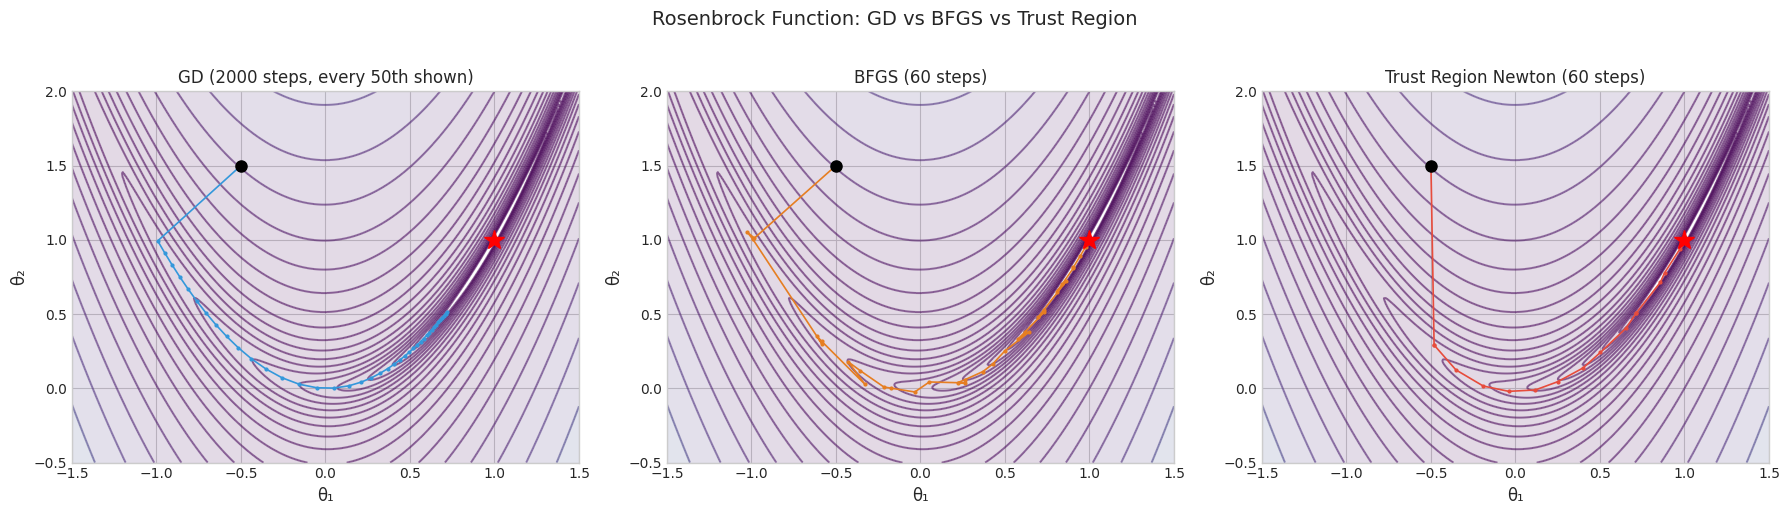

In [23]:
# Visualize on Rosenbrock
t1_rb = np.linspace(-1.5, 1.5, 300)
t2_rb = np.linspace(-0.5, 2.0, 300)
T1_rb, T2_rb = np.meshgrid(t1_rb, t2_rb)
Z_rb = (1 - T1_rb)**2 + 100 * (T2_rb - T1_rb**2)**2

levels_rb = np.logspace(-1, 3.5, 25)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    (path_gd_rb[::50], 'GD (2000 steps, every 50th shown)', '#3498db'),
    (path_bfgs_rb, 'BFGS (60 steps)', '#e67e22'),
    (path_tr, 'Trust Region Newton (60 steps)', '#e74c3c'),
]

for ax, (path, title, color) in zip(axes, methods):
    ax.contour(T1_rb, T2_rb, Z_rb, levels=levels_rb, cmap='viridis', alpha=0.5)
    ax.contourf(T1_rb, T2_rb, Z_rb, levels=levels_rb, cmap='viridis', alpha=0.15)
    ax.plot(path[:, 0], path[:, 1], '.-', color=color, markersize=4, linewidth=1.2)
    ax.plot(*theta0_rb, 'ko', markersize=8)
    ax.plot(1, 1, 'r*', markersize=15)
    ax.set_xlabel('θ₁', fontsize=12)
    ax.set_ylabel('θ₂', fontsize=12)
    ax.set_title(title, fontsize=12)

plt.suptitle('Rosenbrock Function: GD vs BFGS vs Trust Region', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Visualizing the Damping Effect

Let's see how $\lambda$ interpolates between Newton's method ($\lambda = 0$) and gradient descent ($\lambda \to \infty$).

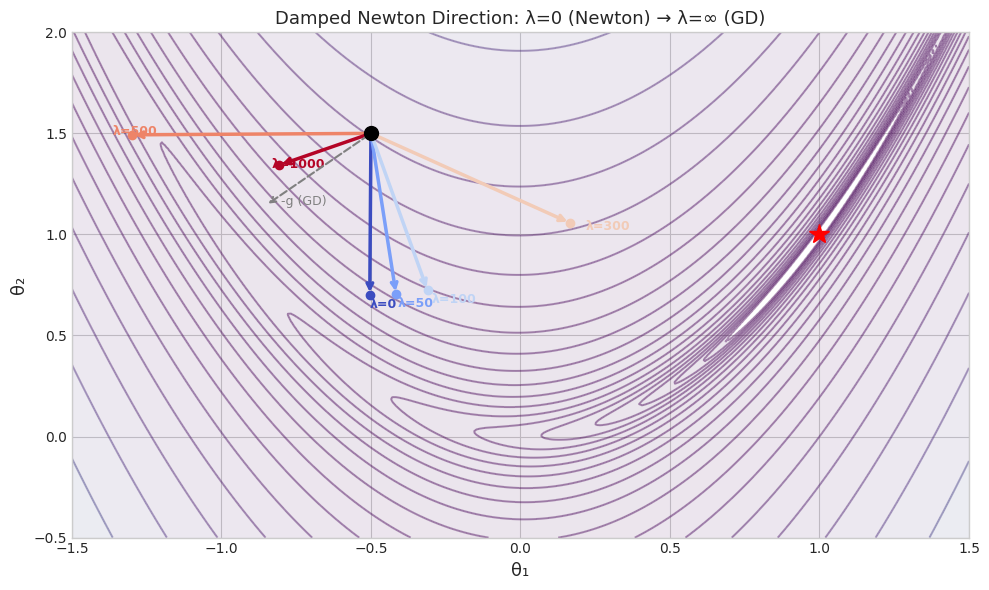

λ = 0: Pure Newton (may be unsafe if H is not positive definite)
λ → ∞: Pure gradient descent (always safe but slow)
Trust region adaptively chooses λ to balance speed and safety.


In [24]:
# Show the effect of lambda on the damped Newton direction
theta_demo = np.array([-0.5, 1.5])
g_demo = rosenbrock_grad(theta_demo)
H_demo = rosenbrock_hess(theta_demo)

lambdas = [0, 50, 100, 300, 500, 1000]

fig, ax = plt.subplots(figsize=(10, 6))
ax.contour(T1_rb, T2_rb, Z_rb, levels=levels_rb, cmap='viridis', alpha=0.4)
ax.contourf(T1_rb, T2_rb, Z_rb, levels=levels_rb, cmap='viridis', alpha=0.1)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(lambdas)))
for lam, col in zip(lambdas, colors):
    H_damped = H_demo + lam * np.eye(2)
    delta = -np.linalg.solve(H_damped, g_demo)
    # Scale for visualization
    scale = min(1.0, 0.8 / np.linalg.norm(delta))
    delta_vis = delta * scale
    ax.annotate('', xy=theta_demo + delta_vis, xytext=theta_demo,
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax.plot(*(theta_demo + delta_vis), 'o', color=col, markersize=6)
    label_pos = theta_demo + delta_vis * 1.08
    ax.text(label_pos[0], label_pos[1], f'λ={lam}', fontsize=9, color=col, fontweight='bold')

ax.plot(*theta_demo, 'ko', markersize=10, zorder=5)
ax.plot(1, 1, 'r*', markersize=15)

# Also show negative gradient direction
neg_g_norm = -g_demo / np.linalg.norm(g_demo) * 0.5
ax.annotate('', xy=theta_demo + neg_g_norm, xytext=theta_demo,
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='--'))
ax.text(theta_demo[0] + neg_g_norm[0] + 0.05, theta_demo[1] + neg_g_norm[1], '-g (GD)',
        fontsize=9, color='gray')

ax.set_xlabel('θ₁', fontsize=13)
ax.set_ylabel('θ₂', fontsize=13)
ax.set_title('Damped Newton Direction: λ=0 (Newton) → λ=∞ (GD)', fontsize=13)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.5, 2.0)
plt.tight_layout()
plt.show()

print("λ = 0: Pure Newton (may be unsafe if H is not positive definite)")
print("λ → ∞: Pure gradient descent (always safe but slow)")
print("Trust region adaptively chooses λ to balance speed and safety.")

## 5. Application: Enzyme Kinetics Parameter Estimation

We now apply these methods to a biotech problem: fitting a **Michaelis-Menten model with substrate inhibition**. The reaction velocity $v$ as a function of substrate concentration $[S]$ is:

$$v = \frac{V_{\max} [S]}{K_m + [S] + [S]^2 / K_i}$$

Parameters:
- $V_{\max}$: maximum reaction velocity
- $K_m$: Michaelis constant (substrate affinity)
- $K_i$: inhibition constant (substrate inhibition strength)

This model creates an ill-conditioned loss landscape: $V_{\max}$ and $K_m$ are strongly correlated, making gradient descent zig-zag. Second-order methods exploit this curvature to converge much faster.

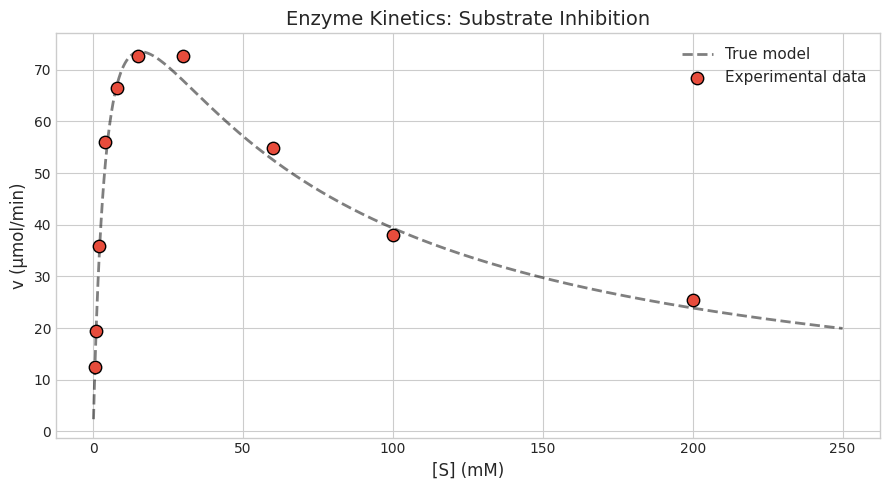

Note the characteristic bell-shaped curve: velocity increases with [S],
reaches a peak, then decreases as substrate inhibition takes over.


In [25]:
# Generate synthetic enzyme kinetics data
true_Vmax = 120.0   # μmol/min
true_Km = 5.0       # mM
true_Ki = 50.0      # mM

def michaelis_menten_inhibition(S, Vmax, Km, Ki):
    """Michaelis-Menten with substrate inhibition."""
    return Vmax * S / (Km + S + S**2 / Ki)

# Experimental substrate concentrations
S_data = np.array([0.5, 1.0, 2.0, 4.0, 8.0, 15.0, 30.0, 60.0, 100.0, 200.0])
v_true = michaelis_menten_inhibition(S_data, true_Vmax, true_Km, true_Ki)
np.random.seed(42)
v_data = v_true + np.random.normal(0, 3.0, len(S_data))
v_data = np.clip(v_data, 0.1, None)

# Plot the data
fig, ax = plt.subplots(figsize=(9, 5))
S_dense = np.linspace(0.1, 250, 500)
ax.plot(S_dense, michaelis_menten_inhibition(S_dense, true_Vmax, true_Km, true_Ki),
        'k--', linewidth=2, alpha=0.5, label='True model')
ax.scatter(S_data, v_data, s=80, c='#e74c3c', edgecolors='black', zorder=5, label='Experimental data')
ax.set_xlabel('[S] (mM)', fontsize=12)
ax.set_ylabel('v (μmol/min)', fontsize=12)
ax.set_title('Enzyme Kinetics: Substrate Inhibition', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Note the characteristic bell-shaped curve: velocity increases with [S],")
print("reaches a peak, then decreases as substrate inhibition takes over.")

In [26]:
# We optimize in log-space: θ = [log(Vmax), log(Km), log(Ki)]
# This ensures positivity and improves conditioning

def loss_enzyme(theta):
    Vmax, Km, Ki = np.exp(np.clip(theta, -20, 20))
    v_pred = michaelis_menten_inhibition(S_data, Vmax, Km, Ki)
    return np.mean((v_data - v_pred)**2)

def grad_enzyme(theta, eps=1e-5):
    """Numerical gradient."""
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        tp, tm = theta.copy(), theta.copy()
        tp[i] += eps
        tm[i] -= eps
        grad[i] = (loss_enzyme(tp) - loss_enzyme(tm)) / (2 * eps)
    return grad

def hess_enzyme(theta, eps=1e-4):
    """Numerical Hessian."""
    D = len(theta)
    H = np.zeros((D, D))
    f0 = loss_enzyme(theta)
    for i in range(D):
        for j in range(i, D):
            tp_ij = theta.copy(); tp_ij[i] += eps; tp_ij[j] += eps
            tp_i = theta.copy(); tp_i[i] += eps
            tp_j = theta.copy(); tp_j[j] += eps
            H[i, j] = (loss_enzyme(tp_ij) - loss_enzyme(tp_i) - loss_enzyme(tp_j) + f0) / eps**2
            H[j, i] = H[i, j]
    return H

# Initial guess (deliberately off)
theta0_enz = np.log([80.0, 2.0, 100.0])  # Vmax=80, Km=2, Ki=100
print(f"Initial guess: Vmax={np.exp(theta0_enz[0]):.0f}, Km={np.exp(theta0_enz[1]):.1f}, Ki={np.exp(theta0_enz[2]):.0f}")
print(f"Initial loss: {loss_enzyme(theta0_enz):.2f}")

Initial guess: Vmax=80, Km=2.0, Ki=100
Initial loss: 48.13


In [27]:
# Run all optimizers
n_steps_enz = 100

# Gradient descent with backtracking
theta_gd_enz = theta0_enz.copy()
path_gd_enz = [theta_gd_enz.copy()]
losses_gd_enz = [loss_enzyme(theta_gd_enz)]
for _ in range(n_steps_enz):
    g = grad_enzyme(theta_gd_enz)
    # Backtracking line search
    eta = 1.0
    f0 = losses_gd_enz[-1]
    for _ in range(30):
        if loss_enzyme(theta_gd_enz - eta * g) < f0 - 1e-4 * eta * (g @ g):
            break
        eta *= 0.5
    theta_gd_enz = theta_gd_enz - eta * g
    path_gd_enz.append(theta_gd_enz.copy())
    losses_gd_enz.append(loss_enzyme(theta_gd_enz))
losses_gd_enz = np.array(losses_gd_enz)

# BFGS
path_bfgs_enz, losses_bfgs_enz = bfgs(loss_enzyme, grad_enzyme, theta0_enz, n_steps=n_steps_enz)

# L-BFGS
path_lbfgs_enz, losses_lbfgs_enz = lbfgs(loss_enzyme, grad_enzyme, theta0_enz, n_steps=n_steps_enz, memory=10)

# Trust region Newton
path_tr_enz, losses_tr_enz = trust_region_newton(
    loss_enzyme, grad_enzyme, hess_enzyme,
    theta0_enz, n_steps=n_steps_enz, lambda_init=10.0)

print("Final losses:")
for name, losses in [
    ('Gradient Descent', losses_gd_enz),
    ('BFGS', losses_bfgs_enz),
    ('L-BFGS (M=10)', losses_lbfgs_enz),
    ('Trust Region Newton', losses_tr_enz),
]:
    print(f"  {name:<25s}: {losses[-1]:.4f}")

Final losses:
  Gradient Descent         : 4.6609
  BFGS                     : 4.0473
  L-BFGS (M=10)            : 4.0473
  Trust Region Newton      : 4.0473


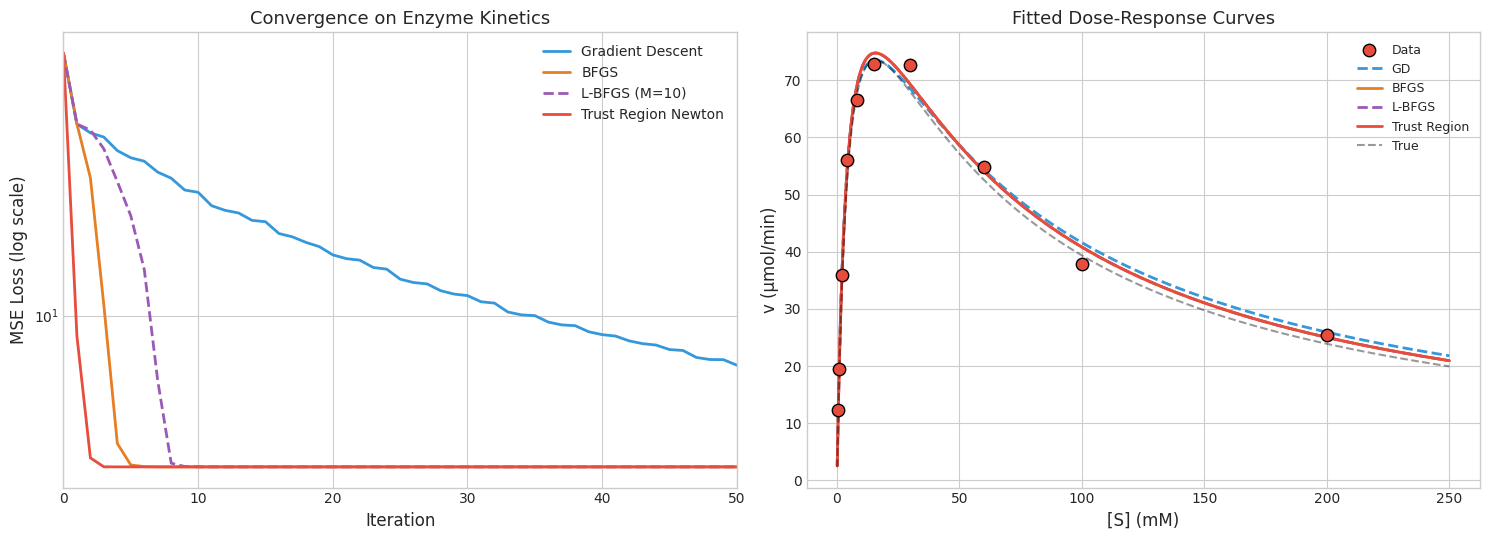

In [28]:
# Convergence and fitted curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: convergence
ax = axes[0]
min_loss = min(losses_gd_enz.min(), losses_bfgs_enz.min(), losses_lbfgs_enz.min(), losses_tr_enz.min())
for losses_i, label, color, ls in [
    (losses_gd_enz, 'Gradient Descent', '#3498db', '-'),
    (losses_bfgs_enz, 'BFGS', '#e67e22', '-'),
    (losses_lbfgs_enz, 'L-BFGS (M=10)', '#9b59b6', '--'),
    (losses_tr_enz, 'Trust Region Newton', '#e74c3c', '-'),
]:
    ax.semilogy(losses_i, linewidth=2, color=color, linestyle=ls, label=label)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('MSE Loss (log scale)', fontsize=12)
ax.set_title('Convergence on Enzyme Kinetics', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 50)

# Right: fitted curves
ax = axes[1]
ax.scatter(S_data, v_data, s=80, c='#e74c3c', edgecolors='black', zorder=5, label='Data')

for path_i, label, color, ls in [
    (np.array(path_gd_enz), 'GD', '#3498db', '--'),
    (path_bfgs_enz, 'BFGS', '#e67e22', '-'),
    (path_lbfgs_enz, 'L-BFGS', '#9b59b6', '--'),
    (path_tr_enz, 'Trust Region', '#e74c3c', '-'),
]:
    theta_f = path_i[-1]
    Vmax_f, Km_f, Ki_f = np.exp(theta_f)
    v_fit = michaelis_menten_inhibition(S_dense, Vmax_f, Km_f, Ki_f)
    ax.plot(S_dense, v_fit, linewidth=2, color=color, linestyle=ls, label=label)

ax.plot(S_dense, michaelis_menten_inhibition(S_dense, true_Vmax, true_Km, true_Ki),
        'k--', linewidth=1.5, alpha=0.4, label='True')
ax.set_xlabel('[S] (mM)', fontsize=12)
ax.set_ylabel('v (μmol/min)', fontsize=12)
ax.set_title('Fitted Dose-Response Curves', fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
# Print parameter estimates
print("Estimated Parameters")
print("=" * 62)
print(f"{'Method':<25s} {'Vmax':>8} {'Km':>8} {'Ki':>8} {'MSE':>8}")
print("-" * 62)
print(f"{'True':.<25s} {true_Vmax:>8.1f} {true_Km:>8.1f} {true_Ki:>8.1f} {'—':>8}")

for path_i, name in [
    (np.array(path_gd_enz), 'Gradient Descent'),
    (path_bfgs_enz, 'BFGS'),
    (path_lbfgs_enz, 'L-BFGS (M=10)'),
    (path_tr_enz, 'Trust Region Newton'),
]:
    Vmax_f, Km_f, Ki_f = np.exp(path_i[-1])
    mse = loss_enzyme(path_i[-1])
    print(f"{name:.<25s} {Vmax_f:>8.1f} {Km_f:>8.1f} {Ki_f:>8.1f} {mse:>8.2f}")

Estimated Parameters
Method                        Vmax       Km       Ki      MSE
--------------------------------------------------------------
True.....................    120.0      5.0     50.0        —
Gradient Descent.........    111.4      4.0     61.1     4.66
BFGS.....................    118.3      4.6     54.0     4.05
L-BFGS (M=10)............    118.3      4.6     54.0     4.05
Trust Region Newton......    118.3      4.6     54.0     4.05


## 6. Summary

### Methods Comparison

| Method | Update Rule | Cost per Step | Memory |
|--------|-----------|:---:|:---:|
| **Newton** | $\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \mathbf{H}_t^{-1}\mathbf{g}_t$ | $O(D^3)$ | $O(D^2)$ |
| **BFGS** | Rank-2 update to $\mathbf{C}_t \approx \mathbf{H}_t^{-1}$ | $O(D^2)$ | $O(D^2)$ |
| **L-BFGS** | Two-loop recursion with $M$ stored pairs | $O(MD)$ | $O(MD)$ |
| **Trust Region** | $\boldsymbol{\delta} = -(\mathbf{H} + \lambda\mathbf{I})^{-1}\mathbf{g}$ | $O(D^3)$ | $O(D^2)$ |

### When to Use What

- **Newton**: Small-to-medium problems where the Hessian is available and the objective is (locally) convex. Converges **quadratically** near the solution.
- **BFGS**: When the Hessian is too expensive to compute but $O(D^2)$ memory is acceptable. Achieves **superlinear** convergence.
- **L-BFGS**: Large-scale problems. The default solver in sklearn's logistic regression. $M = 5$–$20$ pairs usually suffice.
- **Trust Region**: Nonconvex objectives where Newton's method might fail. The damping parameter $\lambda$ adaptively balances Newton's speed with gradient descent's safety.

### Key Takeaways

1. **Curvature information is powerful**: Newton's method converges in 1 step on quadratics, regardless of condition number
2. **The Hessian inverse "undoes" skew**: $\mathbf{H}^{-1}$ transforms elongated contours into circular ones
3. **BFGS builds curvature gradually**: Starting from $\mathbf{C}_0 = \mathbf{I}$, it learns the inverse Hessian from gradient differences
4. **Trust regions ensure safety**: Tikhonov damping $(\mathbf{H} + \lambda\mathbf{I})$ smoothly interpolates between Newton ($\lambda=0$) and gradient descent ($\lambda \to \infty$)